# Feedforward Neural Network - Model Building

# Importing Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reading the dataset

In [3]:
data = pd.read_csv('/content/Preprocessed_dataset_knn(5neighbour).csv')
data.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home
0,Broome,Endicott,New York State Electric & Gas,New York State Electric & Gas,9661.0,Oil,1973,1484,1,Home Performance,...,277.0,24.0,6.826545,0,42.110115,-76.032545,2023,6,22,50
1,Queens,Queens,National Grid,Consolidated Edison,11867.0,Natural Gas,1933,1664,1,Home Performance,...,1062.0,66.0,7.221105,0,40.697715,-73.786045,2023,6,22,90
2,Oswego,Fulton,National Grid,National Grid,9998.0,Natural Gas,1944,1252,1,Home Performance,...,59.0,60.0,6.489205,0,43.325035,-76.411740,2023,6,20,79
3,St. Lawrence,Nicholville,Saint Lawrence Gas,National Grid,6880.0,Oil,1914,1700,1,Home Performance,...,482.0,15.0,6.445720,0,44.695165,-74.704765,2023,6,13,109
4,Oswego,Cleveland,National Grid,National Grid,12289.0,Oil,1891,2680,1,Home Performance,...,690.0,78.0,7.490529,0,43.231255,-75.868192,2023,6,13,132


# Dataset Inspection

In [4]:
data.shape

(51867, 22)

In [5]:
data.dtypes

,0
Project County,object
Project City,object
Gas Utility,object
Electric Utility,object
Total Project Cost,float64
Pre-Retrofit Home Heating Fuel Type,object
Year Home Built,int64
Size Of Home,int64
Number Of Units,int64
Job Type,object


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51867 entries, 0 to 51866
Data columns (total 22 columns):
 #   Column                                                Non-Null Count  Dtype  
---  ------                                                --------------  -----  
 0   Project County                                        51867 non-null  object 
 1   Project City                                          51867 non-null  object 
 2   Gas Utility                                           51867 non-null  object 
 3   Electric Utility                                      51867 non-null  object 
 4   Total Project Cost                                    51867 non-null  float64
 5   Pre-Retrofit Home Heating Fuel Type                   51867 non-null  object 
 6   Year Home Built                                       51867 non-null  int64  
 7   Size Of Home                                          51867 non-null  int64  
 8   Number Of Units                                       51

In [7]:
data.isnull().sum()

,0
Project County,0
Project City,0
Gas Utility,0
Electric Utility,0
Total Project Cost,0
Pre-Retrofit Home Heating Fuel Type,0
Year Home Built,0
Size Of Home,0
Number Of Units,0
Job Type,0


In [8]:
data[data['First Year Modeled Project Energy Savings $ Estimate'].isna()]

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Year Home Built,Size Of Home,Number Of Units,Job Type,...,Estimated Annual kWh Savings,Estimated Annual MMBtu Savings,First Year Modeled Project Energy Savings $ Estimate,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home


# Dropping null values as the number of null values is less than 1%

In [9]:
data = data.dropna()

In [10]:
data.isnull().sum()

,0
Project County,0
Project City,0
Gas Utility,0
Electric Utility,0
Total Project Cost,0
Pre-Retrofit Home Heating Fuel Type,0
Year Home Built,0
Size Of Home,0
Number Of Units,0
Job Type,0


# Building new feature columns and dropping the existing ones to solve for multicollinearity

In [11]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Year Home Built', 'Size Of Home', 'Number Of Units', 'Job Type',
       'Type Of Dwelling', 'Measure Type', 'Estimated Annual kWh Savings',
       'Estimated Annual MMBtu Savings',
       'First Year Modeled Project Energy Savings $ Estimate',
       'size_of_home_flag', 'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home'],
      dtype='object')

# Age of House

In [12]:
data['Age of Home'] = data['Project Completion Year'] - data['Year Home Built']
data['Age of Home'].describe()

,Age of Home
count,51867.000000
mean,72.443326
std,29.468805
min,0.000000
25%,54.000000
50%,73.000000
75%,90.000000
max,233.000000


# Normalisation of data points

## Project Cost

In [13]:
data['Cost_per_Sqft'] = data['Total Project Cost'] / data['Size Of Home']
data['log_cost_per_Sqft'] = np.log(data['Cost_per_Sqft'] + 1)
data.rename(columns={'First Year Modeled Project Energy Savings $ Estimate': 'Log_Annual_Savings_Estimate_in_$'}, inplace=True)
data.drop(columns='Cost_per_Sqft', inplace=True)

## Energy Savings Features

In [14]:
data['kWh_savings_per_Sqft'] = data['Estimated Annual kWh Savings'] / data['Size Of Home']
data['MMBtu_savings_per_Sqft'] = data['Estimated Annual MMBtu Savings'] / data['Size Of Home']

In [15]:
data['total_energy_savings_kwh'] = (
    data['Estimated Annual kWh Savings'] +
    data['Estimated Annual MMBtu Savings'] * 293.071
)
data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh'] / data['Size Of Home']

In [16]:
q1 = data['total_energy_savings_kwh_sqft'].quantile(0.01)
q99 = data['total_energy_savings_kwh_sqft'].quantile(0.99)
data['total_energy_savings_kwh_sqft'] = data['total_energy_savings_kwh_sqft'].clip(q1, q99)

# Dropping redundant columns

In [17]:
data.drop(columns=['Estimated Annual kWh Savings', 'Estimated Annual MMBtu Savings', 'total_energy_savings_kwh'], inplace=True)
data.drop(columns=['Year Home Built', 'MMBtu_savings_per_Sqft', 'kWh_savings_per_Sqft'], inplace=True)

In [18]:
data.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'Log_Annual_Savings_Estimate_in_$', 'size_of_home_flag',
       'Location_1_latitude', 'Location_1_Longitude',
       'Project Completion Year', 'Project Completion Month',
       'Project Completion Day', 'Age of Home', 'log_cost_per_Sqft',
       'total_energy_savings_kwh_sqft'],
      dtype='object')

# Target Variable

In [19]:
data['Log_Annual_Savings_Estimate_in_$'].describe()

,Log_Annual_Savings_Estimate_in_$
count,51867.000000
mean,5.854329
std,0.875218
min,0.000000
25%,5.356586
50%,5.958425
75%,6.444131
max,10.199547


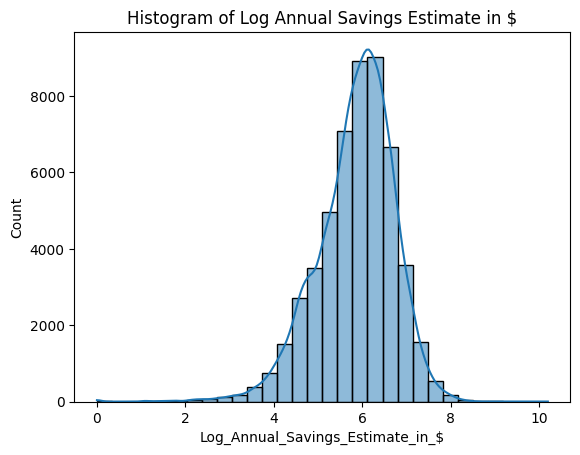

In [20]:
sns.histplot(data['Log_Annual_Savings_Estimate_in_$'], bins=30, kde=True)
plt.title('Histogram of Log Annual Savings Estimate in $')
plt.show()

# Splitting the data into target variable (y) and independent variables (X)

In [21]:
y = data['Log_Annual_Savings_Estimate_in_$']
X = data.drop(columns=['Log_Annual_Savings_Estimate_in_$'])

In [22]:
X.columns

Index(['Project County', 'Project City', 'Gas Utility', 'Electric Utility',
       'Total Project Cost', 'Pre-Retrofit Home Heating Fuel Type',
       'Size Of Home', 'Number Of Units', 'Job Type', 'Type Of Dwelling',
       'Measure Type', 'size_of_home_flag', 'Location_1_latitude',
       'Location_1_Longitude', 'Project Completion Year',
       'Project Completion Month', 'Project Completion Day', 'Age of Home',
       'log_cost_per_Sqft', 'total_energy_savings_kwh_sqft'],
      dtype='object')

# Encoding of categorical variables

## Label Encoding

In [23]:
from sklearn.preprocessing import LabelEncoder

cat_col = X.select_dtypes(include=['object']).columns
le = LabelEncoder()
for col in cat_col:
    X[col] = le.fit_transform(X[col])
X.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,log_cost_per_Sqft,total_energy_savings_kwh_sqft
0,3,425,7,5,9661.0,4,1484,1,1,2,0,0,42.110115,-76.032545,2023,6,22,50,2.016250,4.926350
1,40,1103,5,1,11867.0,3,1664,1,1,2,0,0,40.697715,-73.786045,2023,6,22,90,2.095759,12.262431
2,37,488,5,4,9998.0,3,1252,1,1,2,0,0,43.325035,-76.411740,2023,6,20,79,2.195626,14.092061
3,49,937,10,4,6880.0,4,1700,1,1,2,0,0,44.695165,-74.704765,2023,6,13,109,1.618806,2.869450
4,37,260,5,4,12289.0,4,2680,1,1,2,0,0,43.231255,-75.868192,2023,6,13,132,1.720165,8.787141


# Standard Scaler

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
X_scaled.head()

,Project County,Project City,Gas Utility,Electric Utility,Total Project Cost,Pre-Retrofit Home Heating Fuel Type,Size Of Home,Number Of Units,Job Type,Type Of Dwelling,Measure Type,size_of_home_flag,Location_1_latitude,Location_1_Longitude,Project Completion Year,Project Completion Month,Project Completion Day,Age of Home,log_cost_per_Sqft,total_energy_savings_kwh_sqft
0,-1.688746,-0.743469,0.583474,0.448009,0.776243,0.394222,-0.141343,-0.026711,0.200683,0.373341,-0.100847,0.0,-0.390346,0.045745,1.439575,-0.0129,0.715990,-0.761603,0.829620,-0.343753
1,0.845288,0.714950,-0.340983,-1.661844,1.307180,-0.364539,0.145439,-0.026711,0.200683,0.373341,-0.100847,0.0,-1.845611,1.270396,1.439575,-0.0129,0.715990,0.595777,0.972098,1.253140
2,0.639826,-0.607952,-0.340983,-0.079455,0.857352,-0.364539,-0.510972,-0.026711,0.200683,0.373341,-0.100847,0.0,0.861446,-0.160968,1.439575,-0.0129,0.484818,0.222498,1.151056,1.651407
3,1.461675,0.357874,1.970159,-0.079455,0.106916,0.394222,0.202795,-0.026711,0.200683,0.373341,-0.100847,0.0,2.273158,0.769567,1.439575,-0.0129,-0.324287,1.240533,0.117414,-0.791491
4,0.639826,-1.098394,-0.340983,-0.079455,1.408747,0.394222,1.764162,-0.026711,0.200683,0.373341,-0.100847,0.0,0.764819,0.135340,1.439575,-0.0129,-0.324287,2.021027,0.299045,0.496651


# Split the data into train and test split

In [25]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [26]:
print(f'Training set size: {x_train.shape}')
print(f'Test set size: {x_test.shape}')

Training set size: (41493, 20)
Test set size: (10374, 20)


# Feedforward Neural Network (PyTorch)

## Setting up device

In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else
                       'mps' if torch.backends.mps.is_available() else
                       'cpu')
print(f'Using device: {device}')

Using device: cuda


## Preparing PyTorch DataLoaders

In [28]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(x_train.values).to(device)
y_train_tensor = torch.FloatTensor(y_train.values).unsqueeze(1).to(device)
X_test_tensor = torch.FloatTensor(x_test.values).to(device)
y_test_tensor = torch.FloatTensor(y_test.values).unsqueeze(1).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

input_dim = x_train.shape[1]
print(f'Input features: {input_dim}')
print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')

Input features: 20
Training samples: 41493
Test samples: 10374


## Model Architecture

In [29]:
class FeedForwardNN(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout_rate=0.2):
        super(FeedForwardNN, self).__init__()

        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

print('Model class defined.')

Model class defined.


## Training Function

In [30]:
def train_model(model, train_loader, X_test_tensor, y_test_tensor,
                epochs=100, lr=0.001, patience=10):

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)

    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        # Training
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(X_batch)

        train_loss = epoch_loss / len(train_loader.dataset)
        train_losses.append(train_loss)

        # Validation
        model.eval()
        with torch.no_grad():
            val_pred = model(X_test_tensor)
            val_loss = criterion(val_pred, y_test_tensor).item()
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        # Early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch + 1}')
            break

        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch+1:3d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')

    # Restore best model
    model.load_state_dict(best_model_state)
    return train_losses, val_losses

## Architecture Search

We test three architectures of increasing complexity to find the best configuration.

In [31]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

architectures = {
    '1-Layer (64)':          [64],
    '2-Layer (128-64)':      [128, 64],
    '3-Layer (128-64-32)':   [128, 64, 32],
    '4-Layer (256-128-64-32)': [256, 128, 64, 32]
}

results = {}

for name, hidden_dims in architectures.items():
    print(f'\n{"="*50}')
    print(f'Training: {name}')
    print(f'{"="*50}')

    model = FeedForwardNN(input_dim, hidden_dims, dropout_rate=0.2).to(device)

    # Print parameter count
    n_params = sum(p.numel() for p in model.parameters())
    print(f'Parameters: {n_params:,}')

    train_losses, val_losses = train_model(
        model, train_loader, X_test_tensor, y_test_tensor,
        epochs=150, lr=0.001, patience=15
    )

    # Evaluate
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test_tensor).cpu().numpy().flatten()

    y_true = y_test.values
    r2 = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    print(f'\nResults:')
    print(f'  R-squared: {r2:.4f}')
    print(f'  RMSE:      {rmse:.4f}')
    print(f'  MAE:       {mae:.4f}')

    results[name] = {
        'model': model,
        'r2': r2, 'rmse': rmse, 'mae': mae,
        'train_losses': train_losses, 'val_losses': val_losses,
        'y_pred': y_pred, 'n_params': n_params
    }


Training: 1-Layer (64)
Parameters: 1,537
Epoch  10 | Train Loss: 0.5408 | Val Loss: 0.2669
Epoch  20 | Train Loss: 0.4315 | Val Loss: 0.2436
Epoch  30 | Train Loss: 0.3901 | Val Loss: 0.2308
Epoch  40 | Train Loss: 0.3560 | Val Loss: 0.2257
Epoch  50 | Train Loss: 0.3392 | Val Loss: 0.2226
Epoch  60 | Train Loss: 0.3266 | Val Loss: 0.2240
Epoch  70 | Train Loss: 0.3126 | Val Loss: 0.2203
Epoch  80 | Train Loss: 0.2993 | Val Loss: 0.2210
Epoch  90 | Train Loss: 0.2944 | Val Loss: 0.2195
Early stopping at epoch 100

Results:
  R-squared: 0.7165
  RMSE:      0.4683
  MAE:       0.3103

Training: 2-Layer (128-64)
Parameters: 11,393
Epoch  10 | Train Loss: 0.4726 | Val Loss: 0.1807
Epoch  20 | Train Loss: 0.3677 | Val Loss: 0.1580
Epoch  30 | Train Loss: 0.3176 | Val Loss: 0.1480
Epoch  40 | Train Loss: 0.2763 | Val Loss: 0.1446
Epoch  50 | Train Loss: 0.2504 | Val Loss: 0.1333
Epoch  60 | Train Loss: 0.2343 | Val Loss: 0.1306
Epoch  70 | Train Loss: 0.2232 | Val Loss: 0.1270
Epoch  80 | T

## Architecture Comparison

In [32]:
comparison_df = pd.DataFrame({
    name: {'R²': r['r2'], 'RMSE': r['rmse'], 'MAE': r['mae'], 'Parameters': r['n_params']}
    for name, r in results.items()
}).T
comparison_df

,R²,RMSE,MAE,Parameters
1-Layer (64),0.716508,0.468336,0.310328,1537.0
2-Layer (128-64),0.835786,0.356445,0.198906,11393.0
3-Layer (128-64-32),0.840860,0.350895,0.196365,13505.0
4-Layer (256-128-64-32),0.838643,0.353331,0.208334,49601.0


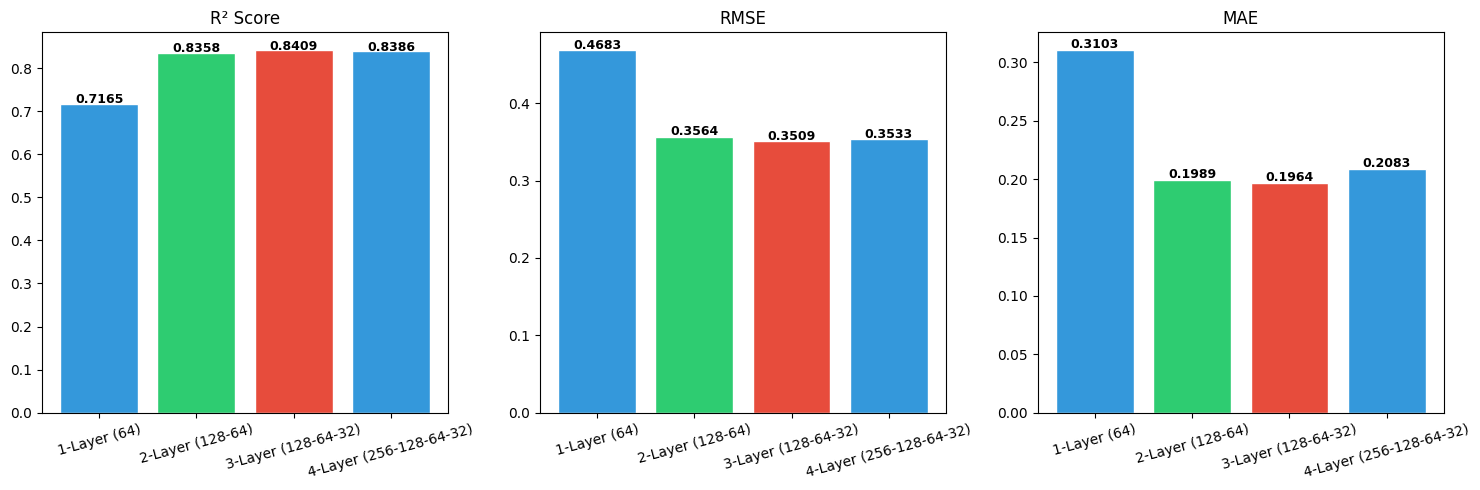

In [33]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

names = list(results.keys())
colors = ['#3498db', '#2ecc71', '#e74c3c']

for ax, metric, title in zip(axes, ['r2', 'rmse', 'mae'], ['R² Score', 'RMSE', 'MAE']):
    vals = [results[n][metric] for n in names]
    bars = ax.bar(names, vals, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

## Select Best Architecture

In [34]:
best_name = max(results, key=lambda k: results[k]['r2'])
best = results[best_name]
best_model = best['model']
y_pred = best['y_pred']

print(f'Best architecture: {best_name}')
print(f'R²:   {best["r2"]:.4f}')
print(f'RMSE: {best["rmse"]:.4f}')
print(f'MAE:  {best["mae"]:.4f}')

Best architecture: 3-Layer (128-64-32)
R²:   0.8409
RMSE: 0.3509
MAE:  0.1964


## Training & Validation Loss Curves

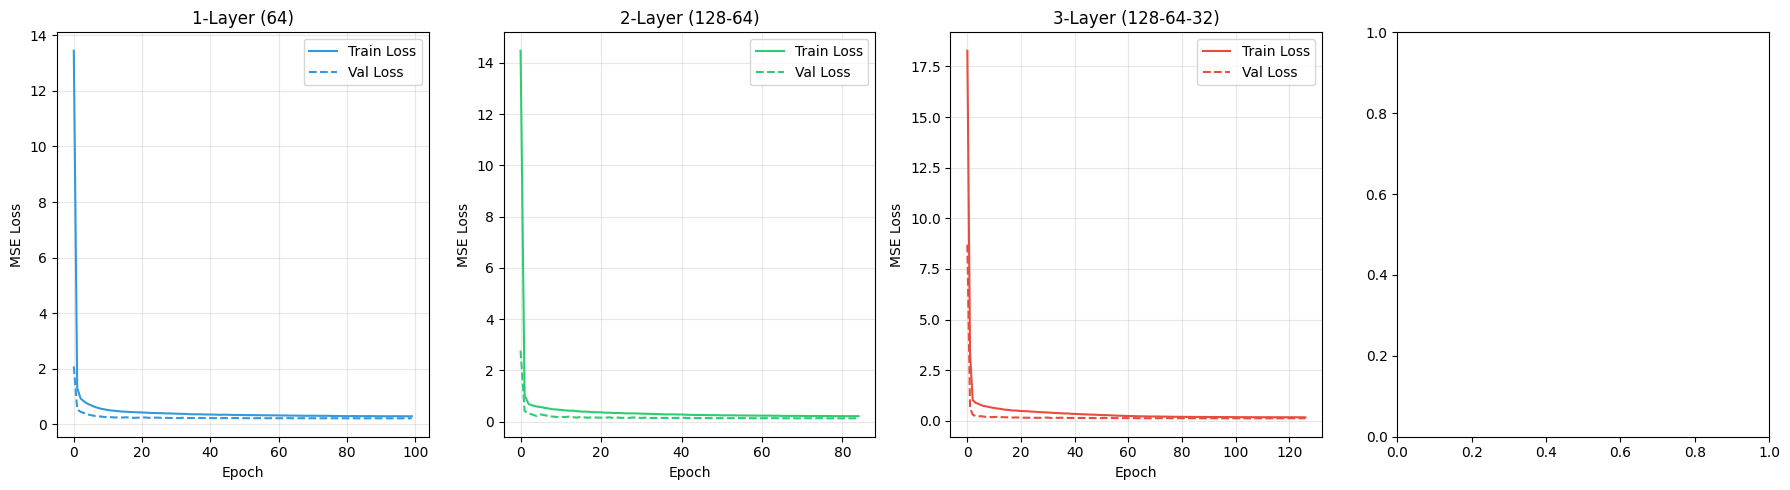

In [35]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

for ax, (name, r), color in zip(axes, results.items(), colors):
    ax.plot(r['train_losses'], label='Train Loss', color=color, linewidth=1.5)
    ax.plot(r['val_losses'], label='Val Loss', color=color, linewidth=1.5, linestyle='--')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title(f'{name}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Accuracy Measure (Best Model)

In [36]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 0.12312719452941905
Root Mean Squared Error: 0.35089484825146555
R-squared: 0.8408597709091719
Mean Absolute Error: 0.19636479470099277


# Residual Analysis

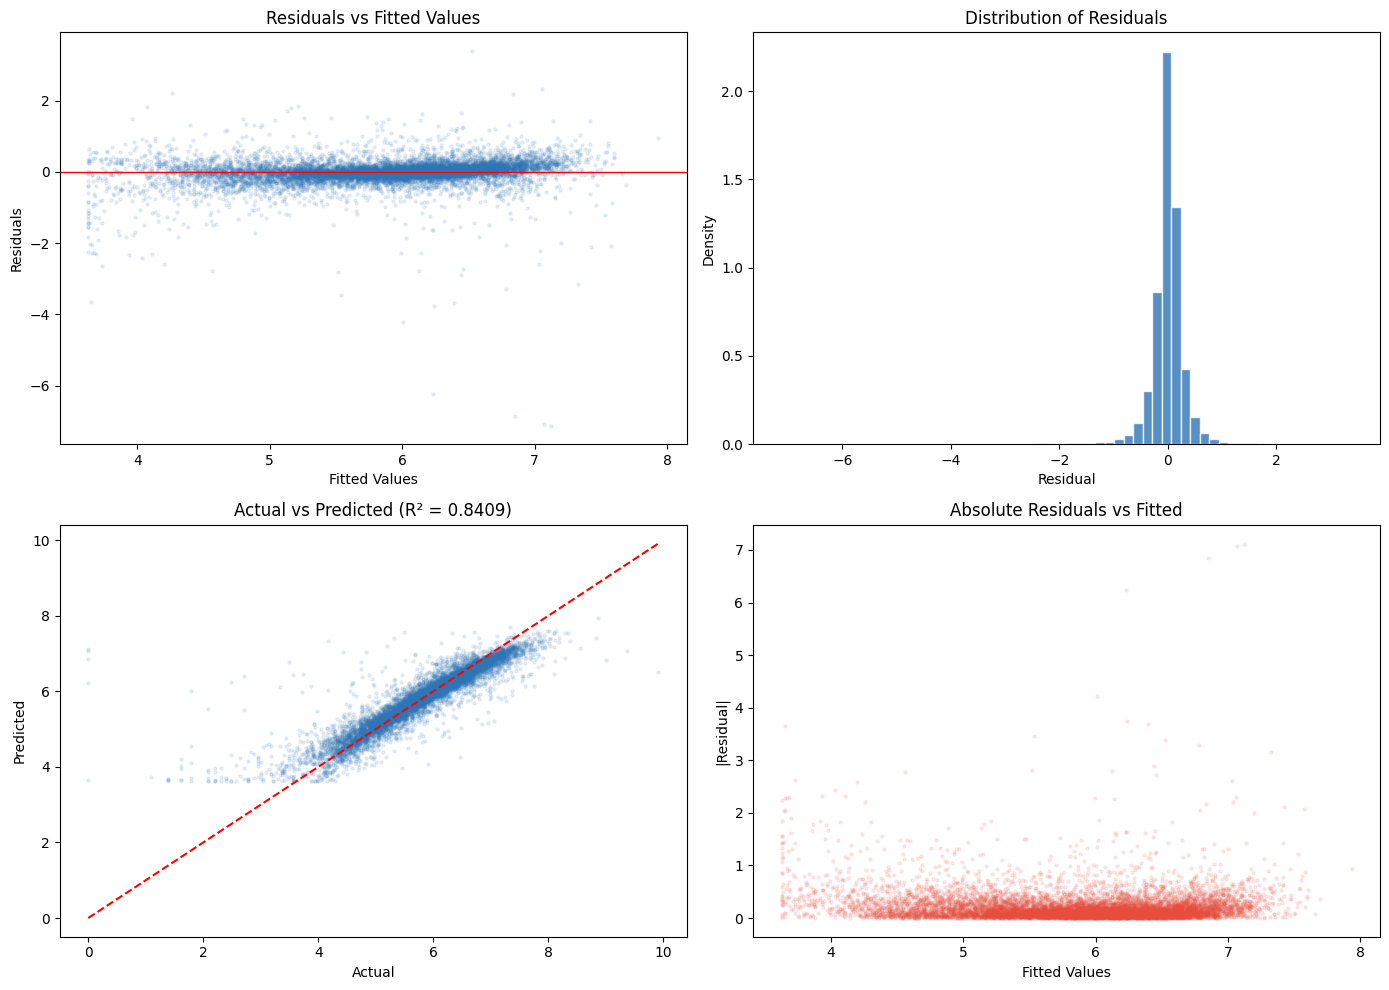

In [37]:
residuals = y_test.values - y_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals vs Fitted
axes[0, 0].scatter(y_pred, residuals, alpha=0.1, s=5, color='#2E75B6')
axes[0, 0].axhline(y=0, color='red', linewidth=1)
axes[0, 0].set_xlabel('Fitted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Fitted Values')

# 2. Histogram of residuals
axes[0, 1].hist(residuals, bins=60, color='#2E75B6', edgecolor='white', alpha=0.8, density=True)
axes[0, 1].set_xlabel('Residual')
axes[0, 1].set_ylabel('Density')
axes[0, 1].set_title('Distribution of Residuals')

# 3. Actual vs Predicted
axes[1, 0].scatter(y_test, y_pred, alpha=0.1, s=5, color='#2E75B6')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
axes[1, 0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5)
axes[1, 0].set_xlabel('Actual')
axes[1, 0].set_ylabel('Predicted')
axes[1, 0].set_title(f'Actual vs Predicted (R² = {r2:.4f})')

# 4. Residual distribution by prediction range
axes[1, 1].scatter(y_pred, np.abs(residuals), alpha=0.1, s=5, color='#e74c3c')
axes[1, 1].set_xlabel('Fitted Values')
axes[1, 1].set_ylabel('|Residual|')
axes[1, 1].set_title('Absolute Residuals vs Fitted')

plt.tight_layout()
plt.show()

# Feature Importance (Permutation Importance)

In [38]:
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

# Wrap PyTorch model for sklearn compatibility
class PyTorchWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model, device):
        self.model = model
        self.device = device

    def fit(self, X, y):
        return self

    def predict(self, X):
        self.model.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X).to(self.device)
            return self.model(X_tensor).cpu().numpy().flatten()

wrapper = PyTorchWrapper(best_model, device)

perm_result = permutation_importance(
    wrapper, x_test, y_test,
    n_repeats=10, random_state=42, scoring='r2'
)

perm_df = pd.DataFrame({
    'Feature': x_test.columns,
    'Importance Mean': perm_result.importances_mean,
    'Importance Std': perm_result.importances_std
}).sort_values('Importance Mean', ascending=False)

perm_df

,Feature,Importance Mean,Importance Std
19,total_energy_savings_kwh_sqft,0.919707,0.010769
6,Size Of Home,0.192239,0.002669
5,Pre-Retrofit Home Heating Fuel Type,0.153774,0.003159
18,log_cost_per_Sqft,0.072341,0.001487
4,Total Project Cost,0.047635,0.001753
12,Location_1_latitude,0.022139,0.000837
14,Project Completion Year,0.021806,0.001000
13,Location_1_Longitude,0.021331,0.000802
3,Electric Utility,0.007015,0.000501
8,Job Type,0.006675,0.000577


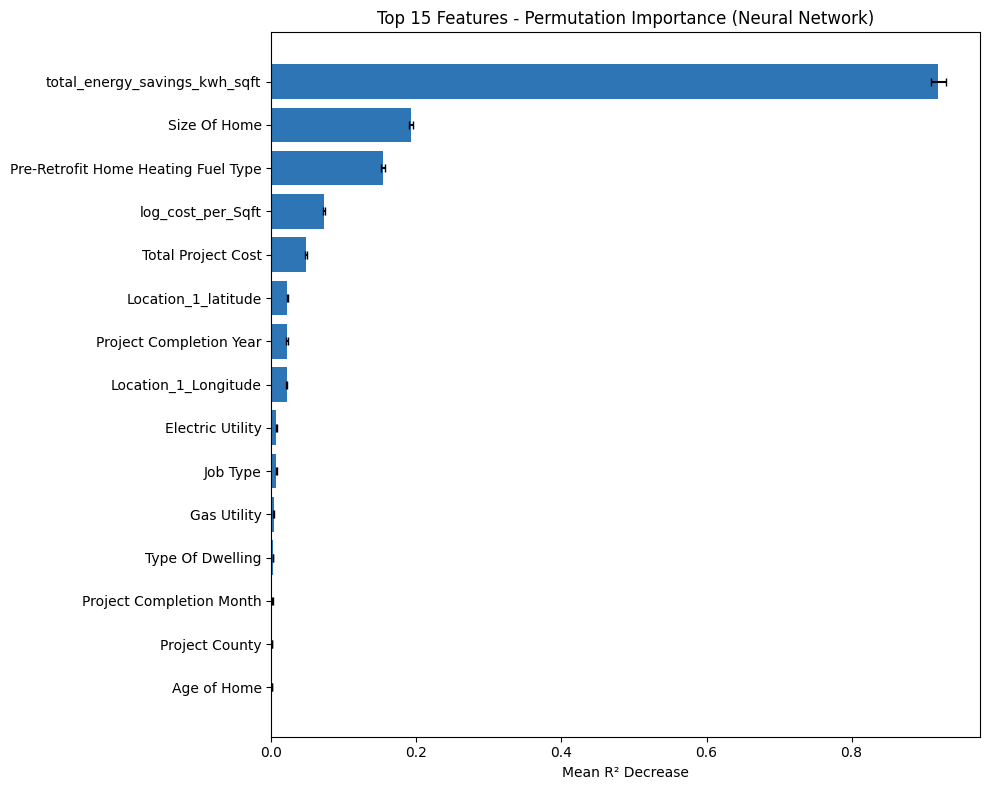

In [39]:
# Feature importance plot
top_features = perm_df.head(15)

plt.figure(figsize=(10, 8))
plt.barh(top_features['Feature'][::-1], top_features['Importance Mean'][::-1],
         xerr=top_features['Importance Std'][::-1], color='#2E75B6', capsize=3)
plt.xlabel('Mean R² Decrease')
plt.title('Top 15 Features - Permutation Importance (Neural Network)')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning (Best Architecture)

Now we tune dropout rate and learning rate for the best architecture.

In [40]:
# Get hidden dims of best architecture
best_hidden = architectures[best_name]
print(f'Tuning architecture: {best_name} = {best_hidden}')

tuning_configs = [
    {'lr': 0.001,  'dropout': 0.1},
    {'lr': 0.001,  'dropout': 0.2},
    {'lr': 0.001,  'dropout': 0.3},
    {'lr': 0.0005, 'dropout': 0.2},
    {'lr': 0.002,  'dropout': 0.2},
]

tuning_results = []

for config in tuning_configs:
    label = f"lr={config['lr']}, dropout={config['dropout']}"
    print(f'\nTraining: {label}')

    model = FeedForwardNN(input_dim, best_hidden, dropout_rate=config['dropout']).to(device)
    train_losses, val_losses = train_model(
        model, train_loader, X_test_tensor, y_test_tensor,
        epochs=150, lr=config['lr'], patience=15
    )

    model.eval()
    with torch.no_grad():
        preds = model(X_test_tensor).cpu().numpy().flatten()

    r2_val = r2_score(y_test, preds)
    rmse_val = np.sqrt(mean_squared_error(y_test, preds))

    print(f'  R²: {r2_val:.4f} | RMSE: {rmse_val:.4f}')
    tuning_results.append({
        'Config': label, 'R²': r2_val, 'RMSE': rmse_val,
        'model': model, 'y_pred': preds
    })

tuning_df = pd.DataFrame(tuning_results)[['Config', 'R²', 'RMSE']]
tuning_df

Tuning architecture: 3-Layer (128-64-32) = [128, 64, 32]

Training: lr=0.001, dropout=0.1
Epoch  10 | Train Loss: 0.4199 | Val Loss: 0.1590
Epoch  20 | Train Loss: 0.3336 | Val Loss: 0.1443
Epoch  30 | Train Loss: 0.2844 | Val Loss: 0.1342
Epoch  40 | Train Loss: 0.2509 | Val Loss: 0.1340
Epoch  50 | Train Loss: 0.2275 | Val Loss: 0.1253
Epoch  60 | Train Loss: 0.2061 | Val Loss: 0.1278
Epoch  70 | Train Loss: 0.1898 | Val Loss: 0.1227
Epoch  80 | Train Loss: 0.1806 | Val Loss: 0.1186
Epoch  90 | Train Loss: 0.1760 | Val Loss: 0.1177
Epoch 100 | Train Loss: 0.1731 | Val Loss: 0.1173
Epoch 110 | Train Loss: 0.1720 | Val Loss: 0.1219
Epoch 120 | Train Loss: 0.1732 | Val Loss: 0.1181
Early stopping at epoch 126
  R²: 0.8478 | RMSE: 0.3432

Training: lr=0.001, dropout=0.2
Epoch  10 | Train Loss: 0.6094 | Val Loss: 0.1930
Epoch  20 | Train Loss: 0.4854 | Val Loss: 0.1585
Epoch  30 | Train Loss: 0.4195 | Val Loss: 0.1407
Epoch  40 | Train Loss: 0.3535 | Val Loss: 0.1355
Epoch  50 | Train Los

,Config,R²,RMSE
0,"lr=0.001, dropout=0.1",0.847794,0.343165
1,"lr=0.001, dropout=0.2",0.843019,0.348506
2,"lr=0.001, dropout=0.3",0.799950,0.393420
3,"lr=0.0005, dropout=0.2",0.836806,0.355336
4,"lr=0.002, dropout=0.2",0.843446,0.348032


In [41]:
# Select best tuned model
best_tuned = max(tuning_results, key=lambda x: x['R²'])
print(f'Best hyperparameters: {best_tuned["Config"]}')
print(f'R²:   {best_tuned["R²"]:.4f}')
print(f'RMSE: {best_tuned["RMSE"]:.4f}')

# Update best predictions
final_model = best_tuned['model']
y_pred_final = best_tuned['y_pred']

Best hyperparameters: lr=0.001, dropout=0.1
R²:   0.8478
RMSE: 0.3432


The Default Pytorch library seems to already have used optimized hyperparamaets as the R² 0.8446 is better than our fine tuned R² of 0.8478.


# Final Accuracy Measure (Tuned Model)

In [42]:
mse = mean_squared_error(y_test, y_pred_final)
r2 = r2_score(y_test, y_pred_final)
mae = mean_absolute_error(y_test, y_pred_final)
rmse = np.sqrt(mse)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rmse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 0.11776252147696385
Root Mean Squared Error: 0.34316544330244536
R-squared: 0.8477935380743218
Mean Absolute Error: 0.18644042179351727


# Summary

In [43]:
print('FEEDFORWARD NEURAL NETWORK - SUMMARY OF RESULTS')
print(f'  Best Architecture:    {best_name}')
print(f'  Best Hyperparams:     {best_tuned["Config"]}')
print(f'  R² (test):            {r2:.4f}')
print(f'  RMSE (test):          {rmse:.4f}')
print(f'  MAE (test):           {mae:.4f}')
print(f'  MSE (test):           {mse:.4f}')

FEEDFORWARD NEURAL NETWORK - SUMMARY OF RESULTS
  Best Architecture:    3-Layer (128-64-32)
  Best Hyperparams:     lr=0.001, dropout=0.1
  R² (test):            0.8478
  RMSE (test):          0.3432
  MAE (test):           0.1864
  MSE (test):           0.1178


The Feed-Forward Neural network from PyTorch gives us a much better result compared to OLS regression. We find an $R^2$ of 0.8408 without Custom hyper-parameter tuning and we get 0.8478 when we do our custom hyper-paramter tuning.